Pruning creates smaller, faster, and more energy-efficient models by systematically removing the least important weights or structures, often with minimal impact on accuracy.

 It works by strategically trimming away the least important connections within the model, much like pruning a plant to encourage healthy growth. 

There are two primary approaches to pruning:

- Unstructured Pruning: This method removes small, individual weights across the network. It targets the weakest connections, regardless of where they are located.
- Structured Pruning: This method removes entire, contiguous blocks of the model that contribute the least to its performance. This could mean removing entire filters in a CNN or attention heads in a Large Language Model (LLM).

Unstructured pruning offers maximum model compression by removing individual low-magnitude weights, but the resulting irregular sparsity can limit inference speed-ups on standard hardware.

##### Unstructured Pruning (Short Notes)

* Removes individual low-importance weights (usually small magnitude weights).

* Steps:

  1. Compute `|W|`
  2. Rank weights
  3. Zero out smallest weights

* Uses a **binary mask**:
 W' = M ⊙ W,  

* **Sparsity** = fraction of weights set to zero.

 Formula for sparsity: Sparsity = (Number of zero weights) / (Total number of weights)

* Threshold-based pruning:
Formula for threshold-based pruning: M[i,j] = 0 if |W[i,j]| < threshold else 1
 
* **Scheduled pruning** gradually increases sparsity during training for better accuracy recovery.
* Benefits:

  * High compression
  * Reduced memory usage
* Limitation:

  * Irregular sparse patterns → limited inference speedup on normal GPUs/CPUs without sparse hardware support.


We define a set of functions to perform global magnitude pruning. This process gathers all linear layer weights, calculates a single global threshold that identifies the 20% of weights with the smallest absolute values, and then sets those weights to zero. This is more efficient than allocating a giant tensor with all weights.

A potential downside of global pruning is that it might excessively prune smaller layers while leaving larger ones almost untouched, which could disproportionately affect certain model capabilities. To achieve uniform layer-wise pruning, you would need to calculate a separate pruning threshold for each layer

| Component   | What Represents a Neuron           | What Pruning Does           |
| ----------- | ---------------------------------- | --------------------------- |
| `gate_proj/up_proj` | One row = one neuron               | Removes low-importance rows |
| `down_proj` | One column = one neuron connection | Removes matching columns    |


* Compute importance of each row using L1 norm.
* Select lowest-importance rows.
* Set entire rows to zero.
* Remove corresponding columns in `down_proj`.


| Before             | After Pruning |
| ------------------ | ------------- |
| `[1,2,3]`          | `[1,2,3]`     |
| `[0.01,0.02,0.01]` | `[0,0,0]`     |

The zeroed row means that neuron is effectively removed.


##### Attention

| Layer    | Main Role             | What It Learns                       | Intuition                      |
| -------- | ---------------------- | ------------------ | ---------------------- |
| `q_proj` | Create Queries        | What each token wants to find        | “What am I searching for?”     |
| `k_proj` | Create Keys           | What information each token contains | “What information do I offer?” |
| `v_proj` | Create Values         | Actual token content/features        | “Here is my information.”      |
| `o_proj` | Merge Attention Heads | Combine all attended information     | “Combine everything learned.”  |


| Step              | Formula         | Shape                     |
| ----------------- | --------------- | ------------------------- |
| Input             | `X`             | `[B, S, H]`               |
| Queries           | `Q = XWq`       | `[B, S, H]`               |
| Keys              | `K = XWk`       | `[B, S, H]`               |
| Values            | `V = XWv`       | `[B, S, H]`               |
| Split Heads       | reshape         | `[B, heads, S, head_dim]` |
| Attention Scores  | `QKᵀ / sqrt(d)` | `[B, heads, S, S]`        |
| Softmax           | probabilities   | `[B, heads, S, S]`        |
| Weighted Sum      | `Attn @ V`      | `[B, heads, S, head_dim]` |
| Merge Heads       | concat          | `[B, S, H]`               |
| Output Projection | `o_proj`        | `[B, S, H]`               |


MLP

In [ ]:
### hidden_state
###    ↓
### gate_proj / up_proj
###    ↓
### expanded neurons
###    ↓
### down_proj
###    ↓
### back to hidden size

: 

| Layer       | Input Shape   | Weight Shape      | Output Shape  | Main Role             | What It Learns             | Intuition                        |
| ----------- | ------------- | ----------------- | ------------- | --------------------- | -------------------------- | -------------------------------- |
| `gate_proj` | `[B,S,H]`     | `[inner, hidden]` | `[B,S,inner]` | Create gating signal  | Which features matter       | “How much should this activate?” |
| `up_proj`   | `[B,S,H]`     | `[inner, hidden]` | `[B,S,inner]` | Expand representation | Richer feature space       | “Create more features.”          |
| `down_proj` | `[B,S,inner]` | `[hidden, inner]` | `[B,S,H]`     | Compress back         | Final transformed features | “Return to model dimension.”     |


##### Structured Pruning + Rebuilding Workflow

| Step                 | Purpose                       | What Happens                                                |
| -------------------- | ----------------------------- | ----------------------------------------------------------- |
| Load Model           | Prepare model for inference   | Load tokenizer + FP16 model, move to GPU/CPU, set `.eval()` |
| Measure Baseline     | Capture original performance  | Measure latency, throughput, GPU memory, and perplexity     |
| Structured Pruning   | Remove less important neurons | Entire rows/columns in MLP projections are zeroed out       |
| Rebuild Architecture | Physically shrink network     | Create smaller linear layers using only surviving neurons   |
| Re-measure & Save    | Compare improvements          | Measure new metrics and compute reduced disk size           |

---

##### Important Functions

| Function                     | Role                               |
| ---------------------------- | ---------------------------------- |
| `load_model_and_tokenizer()` | Loads tokenizer + FP16 model       |
| `measure_baseline()`         | Captures original metrics          |
| `prune_mlp_rows_and_cols()`  | Applies structured pruning         |
| `rebuild_mlp_blocks()`       | Creates smaller dense MLP layers   |
| `measure_rebuilt()`          | Measures rebuilt model performance |
| `save_and_report_size()`     | Saves model and computes size      |

---

##### What Structured Pruning Does

###### Before Pruning

MLP layers contain full dense matrices:

```text
gate_proj : [inner, hidden]
up_proj   : [inner, hidden]
down_proj : [hidden, inner]
```

###### During Pruning

* Entire neurons are removed.
* Rows removed from:

  * `gate_proj`
  * `up_proj`
* Matching columns removed from:

  * `down_proj`

This keeps tensor dimensions logically aligned.

---

##### Why Rebuilding is Necessary

After pruning:

* Weights become mostly zeros.
* Tensor dimensions remain unchanged.
* GPU still processes full matrices.

Rebuilding:

* Removes zeroed neurons permanently.
* Creates smaller matrices.
* Reduces:

  * VRAM usage
  * Disk size
  * Compute cost

---

##### Performance Comparison

| Metric          | Baseline   | Rebuilt    | Effect               |
| --------------- | ---------- | ---------- | -------------------- |
| Latency         | 1.164s     | 1.141s     | Slightly faster      |
| Throughput      | 43.0 tok/s | 43.8 tok/s | Slight improvement   |
| Peak GPU Memory | 2129.6 MiB | 1469.6 MiB | Large reduction      |
| Perplexity      | 4.557      | 428383.216 | Massive quality drop |
| Model Size      | ~Original  | 1372.2 MiB | Much smaller         |

---

##### Key Insight

Structured pruning alone creates sparse weights but does not reduce actual compute cost.

Architectural rebuilding converts sparsity into real efficiency gains by creating physically smaller layers.

---

##### Main Trade-off

| Benefit                     | Cost                          |
| --------------------------- | ----------------------------- |
| Lower memory usage          | Reduced model quality         |
| Smaller disk footprint      | Higher perplexity             |
| Potential inference speedup | Possible accuracy degradation |

---

##### Overall Takeaway

Structured pruning + rebuilding is an effective compression technique for reducing model size and VRAM, but aggressive pruning can severely damage model quality, so pruning ratios must be carefully tuned. 


In [ ]:
def prune_mlp_rows_and_cols(model, prune_frac):
    model.cpu()

    for layer in model.model.layers:
        gate = layer.mlp.gate_proj
        up   = layer.mlp.up_proj
        down = layer.mlp.down_proj

        ### Prune rows
        for proj in (gate, up):
            prune.ln_structured(
                proj,
                name="weight",
                amount=prune_frac,
                n=1,
                dim=0
            )
            prune.remove(proj, "weight")

        ### Prune corresponding columns
        prune.ln_structured(
            down,
            name="weight",
            amount=prune_frac,
            n=1,
            dim=1
        )
        prune.remove(down, "weight")

    return model

In [ ]:
def rebuild_mlp_blocks(model):

    for layer in model.model.layers:

        old_gate = layer.mlp.gate_proj
        old_up   = layer.mlp.up_proj
        old_down = layer.mlp.down_proj

        ### Keep non-zero neurons
        keep_idx = (
            old_gate.weight.data.abs().sum(dim=1) != 0
        ).nonzero(as_tuple=False).view(-1)

        hidden = old_gate.in_features
        inner_new = len(keep_idx)

        ### Smaller layers
        new_gate = nn.Linear(hidden, inner_new, bias=False)
        new_up   = nn.Linear(hidden, inner_new, bias=False)
        new_down = nn.Linear(inner_new, hidden, bias=False)

        ### Copy surviving weights
        new_gate.weight.data = old_gate.weight.data[keep_idx]
        new_up.weight.data   = old_up.weight.data[keep_idx]
        new_down.weight.data = old_down.weight.data[:, keep_idx]

        ### Replace layers
        layer.mlp.gate_proj = new_gate
        layer.mlp.up_proj   = new_up
        layer.mlp.down_proj = new_down

    return model

To effectively combine pruning and quantization, always prune the model first and then apply mask-aware post-training quantization to preserve sparsity and maximize performance gains.

Pruning first means the quantization step has fewer weights to process, making its calibration phase faster. If you quantize first, the zero values introduced by pruning can be confused with other quantized values, which can harm the accuracy of the final model.

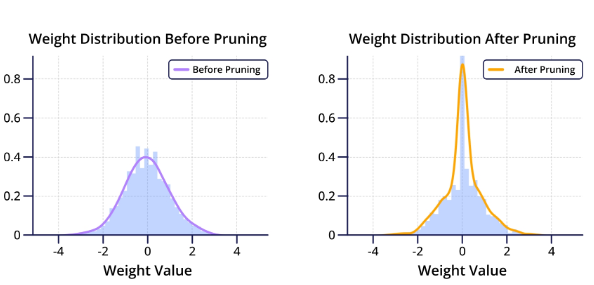

 Pruning creates a weight distribution with a large number of exact zeros. Mask-Aware Quantization. This process teaches the calibrator to ignore the pruned weights. By providing the pruning mask during calibration, the algorithm calculates the scale and zero-point using only the remaining, non-zero weights. This ensures that true zeros in the pruned model remain true zeros after quantization, preserving the model's sparsity for efficient inference.

##### Structured Pruning

### Pruning Overview

| Component         | Purpose                      | Important Code                        | Key Idea                  |
| ----------------- | ---------------------------- | ------------------------------------- | ------------------------- |
| Attention Pruning | Remove weak attention heads  | `prune_attention_heads_logical_gqa()` | Zero weak heads           |
| FFN Pruning       | Remove weak neurons/channels | `prune_ffn_channels_logical_mask()`   | Zero weak FFN channels    |
| Logical Masking   | Keep architecture unchanged  | `weight.mul_(mask)`                   | Only deactivate weights   |
| Importance Metric | Find weak channels           | `torch.norm(..., p=1)`                | Low norm = less important |

---

### Attention Head Pruning

| Step                  | Important Code                    | Purpose                             |
| --------------------- | --------------------------------- | ----------------------------------- |
| Find Attention Layers | `find_attn_modules()`             | Locate transformer attention blocks |
| Target Projections    | `q_proj, k_proj, v_proj, o_proj`  | Attention computations              |
| Create Mask           | `mask_q.index_fill_(0, idx_q, 0)` | Mark weak heads                     |
| Apply Mask            | `Wq.mul_(mask_q[:, None])`        | Zero query head weights             |
| Output Masking        | `Wo.mul_(col_mask[None, :])`      | Remove pruned head outputs          |

---

### FFN Channel Pruning

| Step                 | Important Code                           | Purpose                    |
| -------------------- | ---------------------------------------- | -------------------------- |
| Find MLP Layers      | `find_mlp_modules()`                     | Locate FFN blocks          |
| Compute Importance   | `torch.norm(down_W, p=1, dim=0)`         | Measure channel importance |
| Select Weak Channels | `torch.topk(... largest=False)`          | Choose smallest channels   |
| Create Keep Mask     | `keep_mask.index_fill_(0, prune_idx, 0)` | Mark removable channels    |
| Apply Mask           | `weight.mul_(keep_mask)`                 | Disable weak neurons       |

---

### PEFT / LoRA

| Component        | Important Code                                | Purpose                  |
| ---------------- | --------------------------------------------- | ------------------------ |
| Import PEFT      | `from peft import LoraConfig, get_peft_model` | Enable LoRA              |
| Target Modules   | `collect_lora_targets()`                      | Select trainable layers  |
| LoRA Config      | `LoraConfig(r=16, lora_alpha=32)`             | Configure adapters       |
| Attach Adapters  | `get_peft_model(model, lora_cfg)`             | Insert LoRA layers       |
| Trainable Params | `model.print_trainable_parameters()`          | Verify small trainable % |


 


# Find Attention Modules

```python
def find_attn_modules(module):
    for name, m in module.named_modules():
        if all(hasattr(m, x) for x in ["q_proj","k_proj","v_proj","o_proj"]):
            yield name, m
```

# Find FFN Modules

```python
def find_mlp_modules(module):
    for name, m in module.named_modules():
        if all(hasattr(m, x) for x in ["gate_proj","up_proj","down_proj"]):
            yield name, m
```

# Attention Head Pruning

```python
@torch.no_grad()
def prune_attention_heads_logical_gqa(attn_mod, ratio):

    n_keep_q = max(1, int(n_q * (1.0 - ratio)))
    prune_q  = list(range(n_keep_q, n_q))

    Wq = attn_mod.q_proj.weight
    Wq.mul_(mask_q[:, None])

    for pname, rows in (("k_proj", rows_kv), ("v_proj", rows_kv)):
        proj.weight.mul_(mask[:, None])

    Wo = attn_mod.o_proj.weight
    Wo.mul_(col_mask[None, :])
```

# FFN Channel Pruning

```python
@torch.no_grad()
def prune_ffn_channels_logical_mask(mlp_mod, ratio):

    down_W = mlp_mod.down_proj.weight

    col_norms = torch.norm(down_W, p=1, dim=0)

    prune_idx = torch.topk(
        col_norms,
        k=n_prune,
        largest=False
    ).indices

    mlp_mod.down_proj.weight.mul_(keep_mask[None, :])

    for name in ["up_proj","gate_proj"]:
        getattr(mlp_mod, name).weight.mul_(keep_mask[:, None])
```

# Apply Pruning

```python
if PRUNE_MODE == "attn_heads":

    for name, attn in find_attn_modules(model):
        prune_attention_heads_logical_gqa(attn, PRUNE_RATIO)

elif PRUNE_MODE == "ffn_channels":

    for name, mlp in find_mlp_modules(model):
        prune_ffn_channels_logical_mask(
            mlp,
            PRUNE_RATIO,
            intermediate_size
        )
```

# Collect LoRA Targets

```python
def collect_lora_targets(m):

    names = set()

    for n, mod in m.named_modules():

        for key in [
            "q_proj",
            "k_proj",
            "v_proj",
            "o_proj",
            "up_proj",
            "down_proj",
            "gate_proj"
        ]:
            if n.endswith(key):
                names.add(n.split(".")[-1])

    return sorted(list(names))
```

# LoRA Config

```python
lora_cfg = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=targets
)
```

# Attach LoRA

```python
model = get_peft_model(model, lora_cfg)
```

# Training Core

```python
with torch.cuda.amp.autocast():

    out = model(**moved)

    loss = out.loss / GRAD_ACCUM_STEPS

loss.backward()

optimizer.step()

sched.step()
```

# Evaluation

```python
out = model(**moved)

math.exp(total_loss / total_tokens)
```

# Generation

```python
gen_ids = model.generate(
    **enc,
    max_new_tokens=max_new_tokens,
    do_sample=False
)
```

# Merge LoRA

```python
merged = model.merge_and_unload()
```



Advanced structure Pruning

## Exercise A: Constrained Decoding

### Goal

Score predefined answers instead of free generation.

---

### Flow

| Step | Action                          |
| ---- | ------------------------------- |
| 1    | Build image + question prompt   |
| 2    | Tokenize prompt                 |
| 3    | Tokenize candidate answer       |
| 4    | Compute token log-probabilities |
| 5    | Sum total log-probability       |
| 6    | Pick highest-scoring answer     |

---

### Main Code

```python
next_logits = out.logits[:, -1, :]
next_logp   = log_softmax(next_logits, dim=-1)[0, t].item()
total_logp += next_logp
```

```python
input_ids = torch.cat(
    [input_ids, torch.tensor([[t]], device=device)],
    dim=1
)
```

```python
best_ans, best_score = None, float("-inf")

for cand in candidates:
    s = score_answer_logprob(model, processor, pil_img, question, cand)

    if s > best_score:
        best_score, best_ans = s, cand
```

---

## Exercise B: Pruning Ablation

### Goal

Measure:

* Perplexity (quality)
* Images/sec (speed)

after pruning.

---

### Pruning Types

| Type              | Removes         |
| ----------------- | --------------- |
| FFN pruning       | MLP channels    |
| Attention pruning | Attention heads |

---

### Main Code

#### FFN Pruning

```python
prune_ffn_channels_logical_mask(
    mlp,
    ratio,
    intermediate_size
)
```

#### Attention Head Pruning

```python
prune_attention_heads_logical_gqa(
    attn,
    ratio
)
```

#### Throughput Measurement

```python
t0 = time.perf_counter()

_ = predict_with_candidates(
    model,
    processor,
    pil_img,
    "What is in this image?",
    CANDIDATES
)

t1 = time.perf_counter()

elapsed = max(1e-6, t1 - t0)
return float(seen / elapsed)
```

---

### Results

| Mode      | Ratio | PPL  | Img/sec |
| --------- | ----- | ---- | ------- |
| FFN       | 15%   | 262k | 0.46    |
| FFN       | 30%   | 864k | 0.47    |
| Attention | 15%   | 2075 | 0.46    |
| Attention | 30%   | 2075 | 0.46    |

---

### Insights

| Observation               | Meaning                               |
| ------------------------- | ------------------------------------- |
| FFN pruning hurts quality | FFN layers critical                   |
| Attention pruning stable  | Some heads redundant                  |
| Speed unchanged           | Logical masking not true acceleration |

---

## Exercise C: EOS Ablation

### Goal

Show importance of EOS token supervision.

---

### Without EOS

* Repetitive text
* Run-on generation
* Poor stopping behavior

### With EOS

* Proper stopping
* Cleaner outputs
* Lower repetition

---

### Main Code

#### N-gram Creation

```python
def ngrams(tokens, n):
    return [
        " ".join(tokens[i:i+n])
        for i in range(0, max(0, len(tokens)-n+1))
    ]
```

#### Repetition Detection

```python
counts = Counter(ng)

if any(c >= min_repeat for c in counts.values()):
    return True
```

#### Repetition Rate

```python
return sum(
    1 for t in texts
    if looks_repetitive_full(t, **kw)
) / float(n)
```

#### EOS vs No-EOS

```python
rep_eos   = compute_repetition_rate_full(preds_eos)
rep_noeos = compute_repetition_rate_full(preds_noeos)
```

---

## Final Learnings

| Topic                | Learning                           |
| -------------------- | ---------------------------------- |
| Constrained decoding | Picks best candidate via scoring   |
| Teacher forcing      | Computes exact token probabilities |
| FFN pruning          | Highly sensitive                   |
| Attention pruning    | More redundant                     |
| EOS token            | Essential for stopping generation  |

